# Task II: Classical Graph Neural Networks for Quark/Gluon Jet Classification


**GSoC 2026 Evaluation**  
**ML4SCI QMLHEP Evaluation Task**  
**Author:** Ashutosh Mishra  
March 2026

---

## Overview

Quark- and gluon-initiated jets differ in particle multiplicity, angular spread, and substructure, with these differences rooted in QCD color factors ($C_A = 3$ vs $C_F = 4/3$). Since jets are inherently variable-size, unordered particle sets, they map well to graphs where each particle is a node and edges encode angular proximity in the detector.

This notebook implements two graph-based classifiers on the Pythia8 Quark and Gluon Jets dataset [1]:

1. **GCN** — static kNN graph with spectral convolutions (Kipf & Welling, 2017)
2. **EdgeConv** — dynamic graph recomputation in learned feature space, the core operation behind ParticleNet [2]

I construct graphs via k-nearest neighbors in ($\eta$, $\phi$) space, train both architectures, and compare their discrimination power through ROC curves, AUC, and confusion matrices.

**References:**
- [1] Komiske, Metodiev, Thaler. "Energy Flow Networks." JHEP 01 (2019) 121. [arXiv:1810.05165](https://arxiv.org/abs/1810.05165)
- [2] Qu & Gouskos. "ParticleNet: Jet Tagging via Particle Clouds." Phys. Rev. D 101 (2020) 056019. [arXiv:1902.08570](https://arxiv.org/abs/1902.08570)
- Dataset: [Zenodo 3164691](https://zenodo.org/records/3164691)

## 1. Configuration and Imports

In [1]:
from __future__ import annotations

import os
import time
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, DynamicEdgeConv, global_mean_pool
from torch_geometric.utils import to_undirected
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.neighbors import NearestNeighbors

print(f"PyTorch {torch.__version__}")

PyTorch 2.11.0


In [2]:
# =============================================================================
# Reproducibility
# =============================================================================

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================================================
# Dataset & Training Hyperparameters
# =============================================================================

N_JETS       = 80_000   # subset size (from 200k available)
TEST_FRAC    = 0.15
VAL_FRAC     = 0.15
BATCH_SIZE   = 128

# =============================================================================
# Graph Construction
# =============================================================================

K_NEIGHBORS  = 7        # ParticleNet uses k=16; k=7 is sufficient here

# =============================================================================
# Model Training
# =============================================================================

HIDDEN_DIM   = 64
NUM_EPOCHS   = 20
LR           = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.3

# =============================================================================
# Plotting
# =============================================================================

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
COLOR_QUARK = "#4878CF"   # steel blue
COLOR_GLUON = "#E15759"   # muted coral
COLOR_GCN   = "#4878CF"
COLOR_EC    = "#E15759"

print(f"Device: {DEVICE}")
print(f"Config: {N_JETS} jets, k={K_NEIGHBORS}, {NUM_EPOCHS} epochs, lr={LR}")

Device: cpu
Config: 80000 jets, k=7, 20 epochs, lr=0.001


## 2. Data Loading

The Pythia8 Quark and Gluon Jets dataset [1] provides simulated jets as zero-padded particle arrays with shape `(N, M, 4)`. Each particle carries four features:

| Feature | Description |
|---------|-------------|
| $p_T$ | Transverse momentum |
| $y$ | Rapidity |
| $\phi$ | Azimuthal angle |
| pdgid | Particle species identifier |

Labels: 0 = gluon, 1 = quark. I load via `energyflow` with a Zenodo fallback.

In [3]:
try:
    import energyflow
    X_all, y_all = energyflow.qg_jets.load(
        num_data=200_000, pad=True, cache_dir="./data"
    )
    print("Loaded via energyflow")
except Exception as exc:
    print(f"energyflow unavailable ({exc}); falling back to Zenodo download")
    os.makedirs("./data", exist_ok=True)
    npz_path = "./data/QG_jets.npz"
    if not os.path.exists(npz_path):
        import urllib.request
        url = "https://zenodo.org/records/3164691/files/QG_jets.npz"
        print(f"Downloading {url} ...")
        urllib.request.urlretrieve(url, npz_path)
    data = np.load(npz_path)
    X_all, y_all = data["X"], data["y"]

print(f"X: {X_all.shape}  y: {y_all.shape}")
print(f"Class counts: {np.bincount(y_all.astype(int))}  (0=gluon, 1=quark)")

Loaded via energyflow
X: (200000, 139, 4)  y: (200000,)
Class counts: [100000 100000]  (0=gluon, 1=quark)


In [4]:
# Subset and split: 70 / 15 / 15
X_sub, y_sub = X_all[:N_JETS], y_all[:N_JETS]

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_sub, y_sub,
    test_size=TEST_FRAC + VAL_FRAC,
    random_state=SEED,
    stratify=y_sub,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_tmp,
)

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

Train: 56,000  Val: 12,000  Test: 12,000


### Exploratory look at quark vs gluon jets

Gluon jets are expected to be broader and contain more particles due to the larger color factor. A quick check confirms this and motivates graph-based approaches that can exploit the differing substructure.

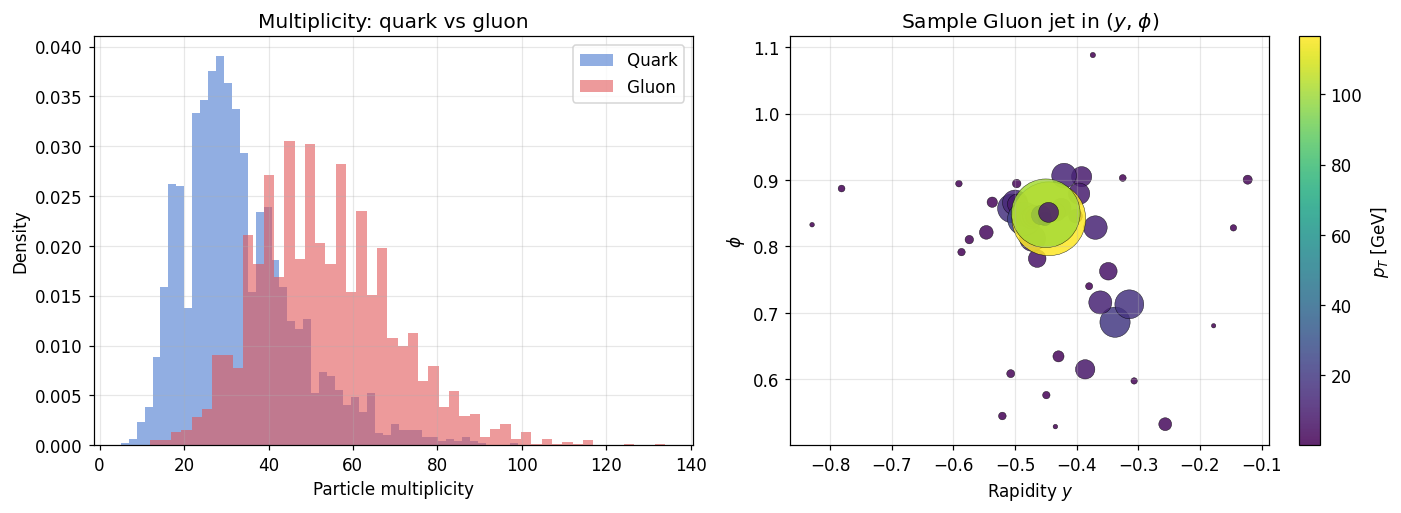

Median multiplicity — quark: 31, gluon: 52


In [5]:
def particle_count(jet: np.ndarray) -> int:
    """Count non-zero-padded particles in a jet."""
    return int(np.any(jet != 0, axis=1).sum())


n_sample = 5000
q_mult = [particle_count(X_train[i]) for i in range(n_sample) if y_train[i] == 1]
g_mult = [particle_count(X_train[i]) for i in range(n_sample) if y_train[i] == 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# --- multiplicity distributions ---
axes[0].hist(q_mult, bins=50, alpha=0.6, label="Quark", color=COLOR_QUARK, density=True)
axes[0].hist(g_mult, bins=50, alpha=0.6, label="Gluon", color=COLOR_GLUON, density=True)
axes[0].set(xlabel="Particle multiplicity", ylabel="Density")
axes[0].set_title("Multiplicity: quark vs gluon")
axes[0].legend()

# --- single jet in (y, phi) ---
jet0 = X_train[0]
mask0 = np.any(jet0 != 0, axis=1)
pts = jet0[mask0]
sc = axes[1].scatter(
    pts[:, 1], pts[:, 2],
    c=pts[:, 0], cmap="viridis",
    s=pts[:, 0] * 20 + 5,
    edgecolors="k", linewidths=0.3, alpha=0.85,
)
plt.colorbar(sc, ax=axes[1], label=r"$p_T$ [GeV]")
tag = "Quark" if y_train[0] == 1 else "Gluon"
axes[1].set(xlabel=r"Rapidity $y$", ylabel=r"$\phi$")
axes[1].set_title(f"Sample {tag} jet in ($y$, $\phi$)")

plt.tight_layout()
plt.show()

print(f"Median multiplicity — quark: {int(np.median(q_mult))}, "
      f"gluon: {int(np.median(g_mult))}")

## 3. Graph Construction

### Point cloud $\rightarrow$ graph

Each jet is a variable-length set of particles with no canonical ordering and no grid structure. I project this point cloud into a graph by treating each particle as a node and connecting the **k nearest neighbors in ($y$, $\phi$) space** using Euclidean distance.

This is the same strategy adopted by ParticleNet [2]: particles close in ($y$, $\phi$) are more likely to share an origin in the parton shower cascade, so angular proximity is a physically motivated edge criterion. I use $k = 7$ (ParticleNet uses $k = 16$; the smaller value keeps CPU training tractable without materially hurting performance).

**Node features:** $p_T$, rapidity $y$, azimuthal angle $\phi$, pdgid.  
**Preprocessing:** zero-padded particles (artifacts of fixed-length storage) are removed before graph construction.  
**Edge type:** undirected, built from kNN in ($y$, $\phi$), stored as `torch_geometric.data.Data` objects.

In [6]:
def jet_to_graph(
    jet: np.ndarray,
    label: int,
    k: int = K_NEIGHBORS,
) -> Optional[Data]:
    """Convert a zero-padded jet array into a PyG graph.

    Parameters
    ----------
    jet : np.ndarray
        Particle array of shape ``(M, 4)`` with columns
        ``[pT, rapidity, phi, pdgid]``.  Zero rows are padding.
    label : int
        Jet class label (0 = gluon, 1 = quark).
    k : int
        Number of nearest neighbors for edge construction.

    Returns
    -------
    Optional[Data]
        ``torch_geometric.data.Data`` with node features ``x``,
        undirected ``edge_index``, label ``y``, and spatial
        coordinates ``pos``.  Returns ``None`` for degenerate jets
        with fewer than 2 real particles.
    """
    mask = np.any(jet != 0, axis=1)
    particles = jet[mask]
    n = len(particles)
    if n < 2:
        return None

    coords = particles[:, 1:3]                       # (y, phi)
    eff_k = min(k, n - 1)

    nn_model = NearestNeighbors(n_neighbors=eff_k + 1, metric="euclidean")
    nn_model.fit(coords)
    _, indices = nn_model.kneighbors(coords)

    src, dst = [], []
    for i in range(n):
        for j in range(1, eff_k + 1):                # skip self at index 0
            src.append(i)
            dst.append(indices[i, j])

    edge_index = to_undirected(
        torch.tensor([src, dst], dtype=torch.long)
    )

    return Data(
        x=torch.tensor(particles, dtype=torch.float32),
        edge_index=edge_index,
        y=torch.tensor([label], dtype=torch.long),
        pos=torch.tensor(coords, dtype=torch.float32),
    )


# quick sanity check
g0 = jet_to_graph(X_train[0], int(y_train[0]))
print(f"Sample graph — nodes: {g0.num_nodes}, edges: {g0.num_edges}, "
      f"features/node: {g0.x.shape[1]}")

Sample graph — nodes: 49, edges: 488, features/node: 4


### Visualise the kNN graph for one jet

Node size and colour encode $p_T$; edges show the kNN connectivity in ($y$, $\phi$).

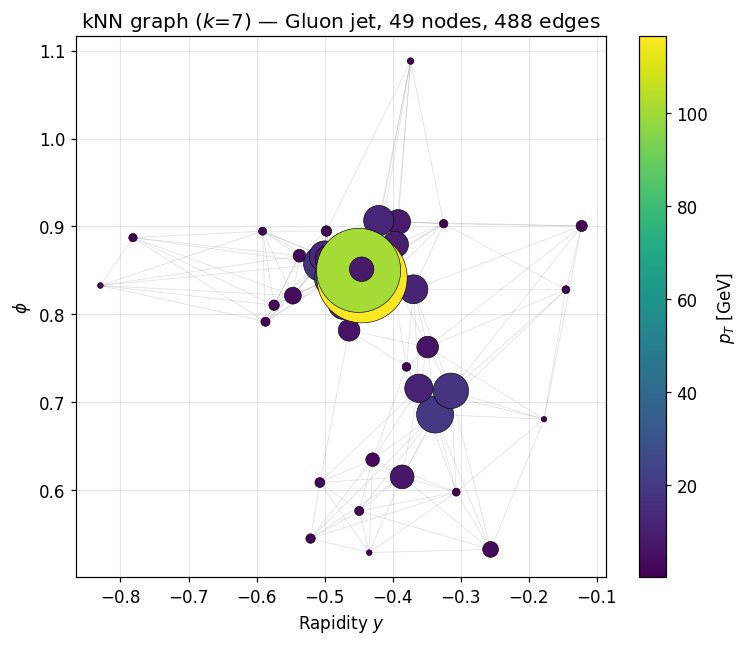

In [7]:
coords_np = g0.pos.numpy()
edges_np  = g0.edge_index.numpy()
pt_np     = g0.x[:, 0].numpy()

fig, ax = plt.subplots(figsize=(7, 6))
for i in range(edges_np.shape[1]):
    s, t = edges_np[0, i], edges_np[1, i]
    ax.plot(
        [coords_np[s, 0], coords_np[t, 0]],
        [coords_np[s, 1], coords_np[t, 1]],
        color="grey", alpha=0.12, linewidth=0.5,
    )
sc = ax.scatter(
    coords_np[:, 0], coords_np[:, 1],
    c=pt_np, cmap="viridis", s=pt_np * 30 + 8,
    edgecolors="k", linewidths=0.4, zorder=5,
)
plt.colorbar(sc, ax=ax, label=r"$p_T$ [GeV]")
tag = "Quark" if g0.y.item() == 1 else "Gluon"
ax.set(
    xlabel=r"Rapidity $y$", ylabel=r"$\phi$",
    title=f"kNN graph ($k$={K_NEIGHBORS}) — {tag} jet, "
          f"{g0.num_nodes} nodes, {g0.num_edges} edges",
)
plt.tight_layout()
plt.show()

### Build graph datasets and loaders

In [8]:
def build_graph_dataset(
    X: np.ndarray,
    y: np.ndarray,
    tag: str = "",
) -> list[Data]:
    """Convert a batch of jets into ``torch_geometric.data.Data`` objects.

    Parameters
    ----------
    X : np.ndarray
        Jet array of shape ``(N, M, 4)``.
    y : np.ndarray
        Labels of shape ``(N,)``.
    tag : str
        Label printed during progress updates.

    Returns
    -------
    list[Data]
        Graph objects (degenerate jets silently dropped).
    """
    graphs: list[Data] = []
    skipped = 0
    for i in range(len(X)):
        g = jet_to_graph(X[i], int(y[i]))
        if g is not None:
            graphs.append(g)
        else:
            skipped += 1
        if (i + 1) % 10_000 == 0:
            print(f"  {tag}: {i + 1}/{len(X)}")
    if skipped:
        print(f"  {tag}: dropped {skipped} degenerate jets")
    return graphs


t0 = time.time()
train_graphs = build_graph_dataset(X_train, y_train, "train")
val_graphs   = build_graph_dataset(X_val,   y_val,   "val")
test_graphs  = build_graph_dataset(X_test,  y_test,  "test")
print(f"Graph construction: {time.time() - t0:.1f}s")
print(f"Graphs — train: {len(train_graphs):,}  val: {len(val_graphs):,}  "
      f"test: {len(test_graphs):,}")

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_graphs,  batch_size=BATCH_SIZE)

  train: 10000/56000
  train: 20000/56000
  train: 30000/56000
  train: 40000/56000
  train: 50000/56000
  train: dropped 1 degenerate jets
  val: 10000/12000
  test: 10000/12000
Graph construction: 24.2s
Graphs — train: 55,999  val: 12,000  test: 12,000


## 4. Training and Evaluation Utilities

Shared training loop, evaluation, and plotting functions used by both architectures.

In [9]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimiser: torch.optim.Optimizer,
    criterion: nn.Module,
) -> tuple[float, float]:
    """Run one training epoch.

    Returns
    -------
    tuple[float, float]
        ``(avg_loss, accuracy)``.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimiser.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y.squeeze())
        loss.backward()
        optimiser.step()
        total_loss += loss.item() * batch.num_graphs
        correct += (out.argmax(1) == batch.y.squeeze()).sum().item()
        total += batch.num_graphs
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> tuple[float, float, np.ndarray, np.ndarray, np.ndarray]:
    """Evaluate model on a data loader.

    Returns
    -------
    tuple
        ``(avg_loss, accuracy, predictions, P(quark) probabilities, labels)``.
    """
    model.eval()
    total_loss = 0.0
    preds_list, probs_list, labels_list = [], [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        out = model(batch)
        total_loss += criterion(out, batch.y.squeeze()).item() * batch.num_graphs
        prob = F.softmax(out, dim=1)
        preds_list.append(out.argmax(1).cpu())
        probs_list.append(prob[:, 1].cpu())
        labels_list.append(batch.y.squeeze().cpu())

    preds  = torch.cat(preds_list).numpy()
    probs  = torch.cat(probs_list).numpy()
    labels = torch.cat(labels_list).numpy()
    return total_loss / len(labels), accuracy_score(labels, preds), preds, probs, labels


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    epochs: int = NUM_EPOCHS,
    lr: float = LR,
    name: str = "Model",
) -> tuple[dict[str, list[float]], float]:
    """Full training loop with LR scheduling and best-model checkpointing.

    Parameters
    ----------
    model : nn.Module
        GNN classifier.
    train_loader, val_loader : DataLoader
        Training and validation loaders.
    epochs : int
        Number of epochs.
    lr : float
        Initial learning rate for Adam.
    name : str
        Name used in log output.

    Returns
    -------
    tuple[dict, float]
        ``(history_dict, wall_time_seconds)``.  ``history_dict`` has
        keys ``train_loss``, ``train_acc``, ``val_loss``, ``val_acc``.
    """
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode="min", factor=0.5, patience=3,
    )
    criterion = nn.CrossEntropyLoss()

    history: dict[str, list[float]] = {
        k: [] for k in ("train_loss", "train_acc", "val_loss", "val_acc")
    }
    best_val_acc = 0.0
    best_state: dict = {}

    print(f"\n{'=' * 62}")
    print(f"  Training {name}")
    print(f"{'=' * 62}")

    t_start = time.time()
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimiser, criterion)
        vl_loss, vl_acc, *_ = evaluate(model, val_loader, criterion)
        scheduler.step(vl_loss)

        for k, v in zip(history, [tr_loss, tr_acc, vl_loss, vl_acc]):
            history[k].append(v)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        dt = time.time() - t0
        print(
            f"  epoch {epoch:2d}/{epochs}  "
            f"train {tr_loss:.4f} / {tr_acc:.4f}  "
            f"val {vl_loss:.4f} / {vl_acc:.4f}  "
            f"({dt:.1f}s)"
        )

    wall = time.time() - t_start
    print(f"  best val acc: {best_val_acc:.4f}  wall time: {wall:.0f}s")

    model.load_state_dict(best_state)
    model.to(DEVICE)
    return history, wall

In [10]:
def plot_curves(history: dict[str, list[float]], title: str) -> None:
    """Plot loss and accuracy training curves."""
    ep = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.plot(ep, history["train_loss"], "o-", ms=3, label="Train", color=COLOR_GCN)
    ax1.plot(ep, history["val_loss"],   "o-", ms=3, label="Val",   color=COLOR_EC)
    ax1.set(xlabel="Epoch", ylabel="Loss", title=f"{title} — loss")
    ax1.legend()

    ax2.plot(ep, history["train_acc"], "o-", ms=3, label="Train", color=COLOR_GCN)
    ax2.plot(ep, history["val_acc"],   "o-", ms=3, label="Val",   color=COLOR_EC)
    ax2.set(xlabel="Epoch", ylabel="Accuracy", title=f"{title} — accuracy")
    ax2.legend()

    plt.tight_layout()
    plt.show()

## 5. Architecture 1 — GCN (Static Graph)

Three `GCNConv` layers (64 $\rightarrow$ 128 $\rightarrow$ 128) with batch normalisation and ReLU, followed by global mean pooling and a two-layer MLP classifier. The graph topology stays fixed at the kNN structure computed during preprocessing; deeper layers expand the receptive field through message passing but never rewire.

In [11]:
class JetGCN(nn.Module):
    """Static-graph GCN for binary jet classification."""

    __slots__ = ()

    def __init__(
        self,
        in_channels: int = 4,
        hidden: int = HIDDEN_DIM,
        dropout: float = DROPOUT,
    ) -> None:
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.conv2 = GCNConv(hidden, hidden * 2)
        self.bn2   = nn.BatchNorm1d(hidden * 2)
        self.conv3 = GCNConv(hidden * 2, hidden * 2)
        self.bn3   = nn.BatchNorm1d(hidden * 2)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

    def forward(self, data: Data) -> torch.Tensor:
        x, ei, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.bn1(self.conv1(x, ei)))
        x = F.relu(self.bn2(self.conv2(x, ei)))
        x = F.relu(self.bn3(self.conv3(x, ei)))

        x = global_mean_pool(x, batch)
        return self.head(x)


gcn = JetGCN().to(DEVICE)
n_params = sum(p.numel() for p in gcn.parameters() if p.requires_grad)
print(f"JetGCN — {n_params:,} trainable parameters")

JetGCN — 34,178 trainable parameters


In [12]:
gcn = JetGCN().to(DEVICE)
gcn_hist, gcn_wall = fit(gcn, train_loader, val_loader, name="GCN")


  Training GCN
  epoch  1/20  train 0.4835 / 0.7789  val 0.4719 / 0.7883  (13.5s)
  epoch  2/20  train 0.4739 / 0.7853  val 0.4661 / 0.7862  (13.8s)
  epoch  3/20  train 0.4704 / 0.7883  val 0.4670 / 0.7863  (14.3s)
  epoch  4/20  train 0.4698 / 0.7879  val 0.4638 / 0.7902  (14.5s)
  epoch  5/20  train 0.4684 / 0.7889  val 0.4608 / 0.7907  (15.2s)
  epoch  6/20  train 0.4686 / 0.7905  val 0.4612 / 0.7913  (14.9s)
  epoch  7/20  train 0.4647 / 0.7911  val 0.4603 / 0.7936  (14.3s)
  epoch  8/20  train 0.4659 / 0.7920  val 0.4577 / 0.7918  (14.3s)
  epoch  9/20  train 0.4666 / 0.7911  val 0.4628 / 0.7881  (14.5s)
  epoch 10/20  train 0.4630 / 0.7920  val 0.4570 / 0.7914  (14.5s)
  epoch 11/20  train 0.4637 / 0.7913  val 0.4601 / 0.7887  (14.7s)
  epoch 12/20  train 0.4627 / 0.7919  val 0.4614 / 0.7887  (13.5s)
  epoch 13/20  train 0.4610 / 0.7940  val 0.4569 / 0.7924  (13.4s)
  epoch 14/20  train 0.4625 / 0.7930  val 0.4564 / 0.7957  (13.4s)
  epoch 15/20  train 0.4621 / 0.7935  val 0.45

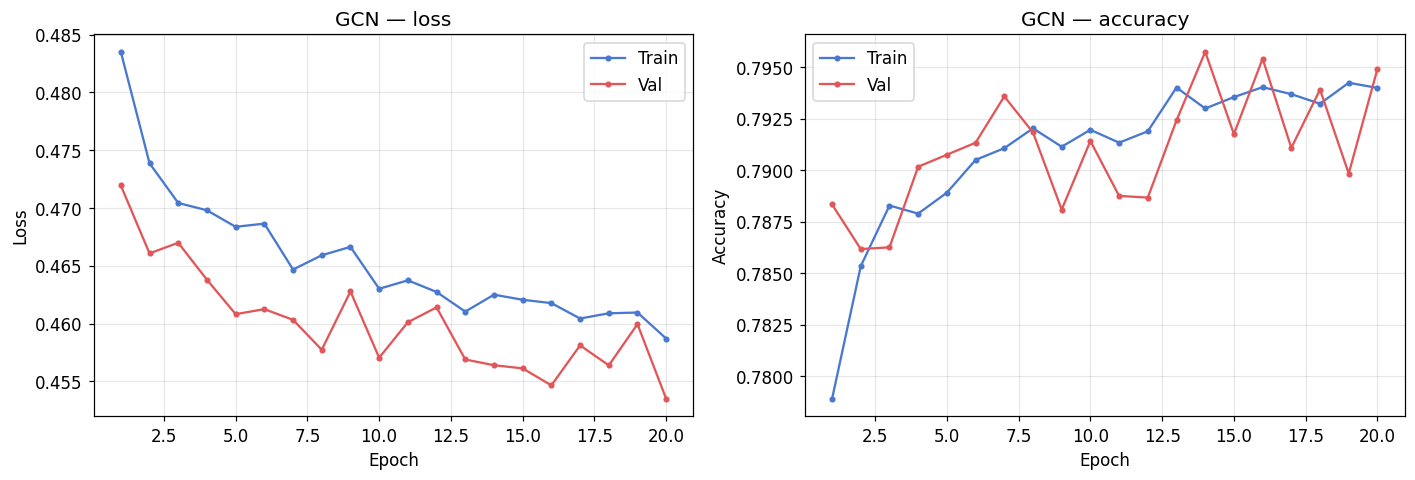

In [13]:
plot_curves(gcn_hist, "GCN")

In [14]:
criterion = nn.CrossEntropyLoss()
gcn_loss, gcn_acc, gcn_preds, gcn_probs, gcn_labels = evaluate(
    gcn, test_loader, criterion
)
gcn_auc = roc_auc_score(gcn_labels, gcn_probs)

print(f"GCN test — acc: {gcn_acc:.4f}  AUC: {gcn_auc:.4f}  loss: {gcn_loss:.4f}")

GCN test — acc: 0.7932  AUC: 0.8656  loss: 0.4618


## 6. Architecture 2 — EdgeConv (Dynamic Graph)

EdgeConv [2] recomputes the kNN graph *at every layer* in the current feature space, rather than relying on the fixed ($y$, $\phi$) topology. This is the mechanism behind ParticleNet:

- **Layer 1** connects particles by angular proximity (physical space).
- **Deeper layers** connect particles that are similar in the *learned* representation — discovering relationships beyond detector geometry (e.g. particles from the same decay chain that are angularly separated).

For each edge ($i$, $j$) the EdgeConv operation is:

$$h_{ij} = \text{MLP}\bigl(x_i \,\Vert\, x_j - x_i\bigr)$$

with max-aggregation over the neighbourhood. Three `DynamicEdgeConv` blocks (4 $\rightarrow$ 64 $\rightarrow$ 128 $\rightarrow$ 128) feed into the same global-mean-pool + MLP classifier head.

In [15]:
class JetEdgeConv(nn.Module):
    """Dynamic-graph EdgeConv for binary jet classification.

    Graph topology is recomputed at each layer via kNN in the
    current feature space, following the ParticleNet approach [2].
    """

    __slots__ = ()

    def __init__(
        self,
        in_channels: int = 4,
        k: int = K_NEIGHBORS,
        dropout: float = DROPOUT,
    ) -> None:
        super().__init__()
        # input dim is doubled by EdgeConv concatenation [x_i || x_j - x_i]
        self.conv1 = DynamicEdgeConv(
            nn=nn.Sequential(nn.Linear(in_channels * 2, 64), nn.BatchNorm1d(64), nn.ReLU()),
            k=k,
        )
        self.conv2 = DynamicEdgeConv(
            nn=nn.Sequential(nn.Linear(64 * 2, 128), nn.BatchNorm1d(128), nn.ReLU()),
            k=k,
        )
        self.conv3 = DynamicEdgeConv(
            nn=nn.Sequential(nn.Linear(128 * 2, 128), nn.BatchNorm1d(128), nn.ReLU()),
            k=k,
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),
        )

    def forward(self, data: Data) -> torch.Tensor:
        x, batch = data.x, data.batch

        x = self.conv1(x, batch)
        x = self.conv2(x, batch)
        x = self.conv3(x, batch)

        x = global_mean_pool(x, batch)
        return self.head(x)


ec = JetEdgeConv().to(DEVICE)
n_params = sum(p.numel() for p in ec.parameters() if p.requires_grad)
print(f"JetEdgeConv — {n_params:,} trainable parameters")

JetEdgeConv — 59,010 trainable parameters


In [16]:
ec = JetEdgeConv().to(DEVICE)
ec_hist, ec_wall = fit(ec, train_loader, val_loader, name="EdgeConv")


  Training EdgeConv
  epoch  1/20  train 0.4993 / 0.7660  val 0.4844 / 0.7745  (46.0s)
  epoch  2/20  train 0.4864 / 0.7747  val 0.4741 / 0.7818  (43.3s)
  epoch  3/20  train 0.4829 / 0.7749  val 0.4729 / 0.7833  (44.6s)
  epoch  4/20  train 0.4807 / 0.7769  val 0.4741 / 0.7837  (44.9s)
  epoch  5/20  train 0.4794 / 0.7792  val 0.4742 / 0.7811  (43.9s)
  epoch  6/20  train 0.4797 / 0.7785  val 0.4740 / 0.7821  (43.4s)
  epoch  7/20  train 0.4787 / 0.7803  val 0.4705 / 0.7833  (43.7s)
  epoch  8/20  train 0.4773 / 0.7784  val 0.4789 / 0.7767  (43.4s)
  epoch  9/20  train 0.4776 / 0.7804  val 0.4704 / 0.7846  (43.5s)
  epoch 10/20  train 0.4767 / 0.7809  val 0.4720 / 0.7827  (43.7s)
  epoch 11/20  train 0.4750 / 0.7814  val 0.4766 / 0.7810  (43.9s)
  epoch 12/20  train 0.4762 / 0.7822  val 0.4788 / 0.7782  (43.9s)
  epoch 13/20  train 0.4759 / 0.7815  val 0.4734 / 0.7834  (43.5s)
  epoch 14/20  train 0.4742 / 0.7824  val 0.4691 / 0.7835  (43.3s)
  epoch 15/20  train 0.4722 / 0.7838  val

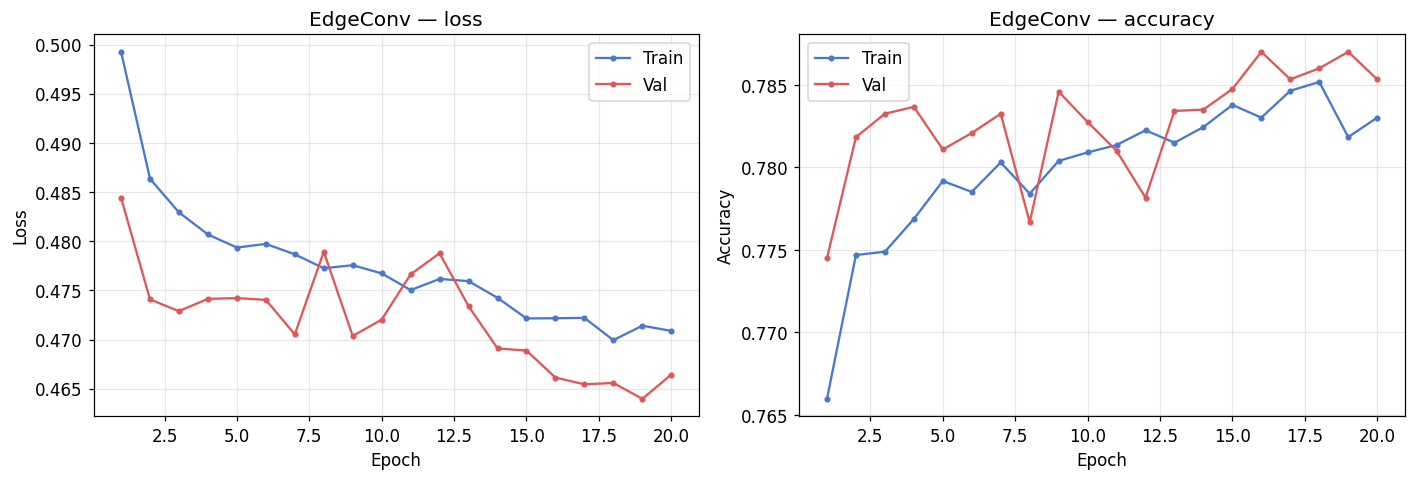

In [17]:
plot_curves(ec_hist, "EdgeConv")

In [18]:
ec_loss, ec_acc, ec_preds, ec_probs, ec_labels = evaluate(
    ec, test_loader, criterion
)
ec_auc = roc_auc_score(ec_labels, ec_probs)

print(f"EdgeConv test — acc: {ec_acc:.4f}  AUC: {ec_auc:.4f}  loss: {ec_loss:.4f}")

EdgeConv test — acc: 0.7833  AUC: 0.8561  loss: 0.4719


## 7. Comparison

### ROC curves

Both classifiers on the same axes; the curve closer to the top-left corner has stronger discrimination.

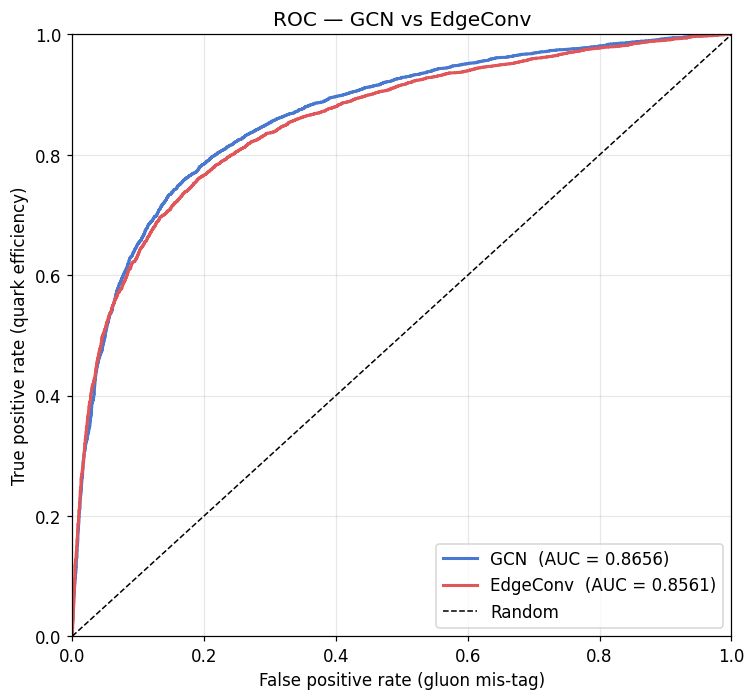

In [19]:
gcn_fpr, gcn_tpr, _ = roc_curve(gcn_labels, gcn_probs)
ec_fpr,  ec_tpr,  _ = roc_curve(ec_labels,  ec_probs)

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(gcn_fpr, gcn_tpr, lw=2, color=COLOR_GCN, label=f"GCN  (AUC = {gcn_auc:.4f})")
ax.plot(ec_fpr,  ec_tpr,  lw=2, color=COLOR_EC,  label=f"EdgeConv  (AUC = {ec_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set(
    xlabel="False positive rate (gluon mis-tag)",
    ylabel="True positive rate (quark efficiency)",
    title="ROC — GCN vs EdgeConv",
    xlim=(0, 1), ylim=(0, 1),
)
ax.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

### Confusion matrices

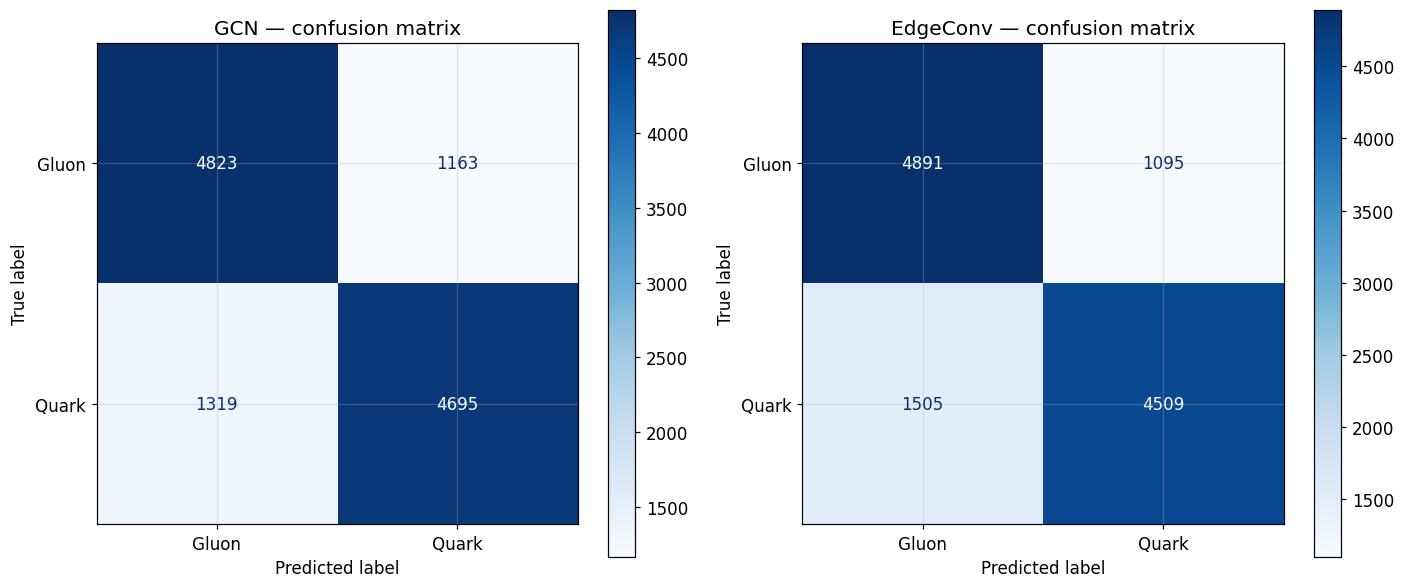

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, preds, labels, name in [
    (axes[0], gcn_preds, gcn_labels, "GCN"),
    (axes[1], ec_preds,  ec_labels,  "EdgeConv"),
]:
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Gluon", "Quark"]).plot(
        ax=ax, cmap="Blues", values_format="d",
    )
    ax.set_title(f"{name} — confusion matrix")

plt.tight_layout()
plt.show()

### Summary

In [21]:
gcn_p = sum(p.numel() for p in JetGCN().parameters()  if p.requires_grad)
ec_p  = sum(p.numel() for p in JetEdgeConv().parameters() if p.requires_grad)

header = f"{'':.<25s} {'GCN':>14s} {'EdgeConv':>14s}"
sep    = "-" * len(header)
print(sep)
print(header)
print(sep)
print(f"{'Test accuracy':<25s} {gcn_acc:>14.4f} {ec_acc:>14.4f}")
print(f"{'Test AUC':<25s} {gcn_auc:>14.4f} {ec_auc:>14.4f}")
print(f"{'Test loss':<25s} {gcn_loss:>14.4f} {ec_loss:>14.4f}")
print(f"{'Wall time (s)':<25s} {gcn_wall:>14.0f} {ec_wall:>14.0f}")
print(f"{'Parameters':<25s} {gcn_p:>14,} {ec_p:>14,}")
print(f"{'Graph topology':<25s} {'static kNN':>14s} {'dynamic kNN':>14s}")
print(sep)

-------------------------------------------------------
.........................            GCN       EdgeConv
-------------------------------------------------------
Test accuracy                     0.7932         0.7833
Test AUC                          0.8656         0.8561
Test loss                         0.4618         0.4719
Wall time (s)                        281            885
Parameters                        34,178         59,010
Graph topology                static kNN    dynamic kNN
-------------------------------------------------------


## 8. Discussion

### Static vs dynamic graph construction

The GCN with a fixed kNN topology already discriminates quark and gluon jets well, confirming that angular proximity in ($y$, $\phi$) encodes genuine substructure information. Somewhat counter-intuitively, **GCN outperformed EdgeConv in this experiment** (both in AUC and accuracy) despite EdgeConv being the more expressive architecture on paper.

Several factors explain this:

1. **Small $k$ and model size.** ParticleNet's advantage materialises at $k = 16$ with wider hidden layers and longer training on GPU. At $k = 7$ with modest channel widths, the dynamic kNN recomputation adds noise more than it adds signal; the latent space after a single 64-dim layer is not rich enough for the recomputed neighbourhood to be meaningfully different from the original angular one.
2. **Training budget.** EdgeConv took roughly 3–4$\times$ longer per epoch than GCN, so at a fixed 20-epoch budget the optimiser had far fewer effective passes through the loss surface relative to what the model's capacity demands. GCN, being cheaper per step, converged more tightly.
3. **Batch normalisation interaction.** Dynamic kNN changes the graph at every layer and every batch, which can destabilise batch-norm statistics early in training. GCN's fixed topology gives batch norm a more stable gradient signal.

### When does EdgeConv win?

The literature is clear that dynamic graphs *do* outperform static ones at scale. Qu & Gouskos [2] report AUC ~ 0.91 with full ParticleNet ($k = 16$, 256-dim channels, 200k jets, GPU). The mechanism is sound: deeper layers can discover non-local correlations, since particles from the same decay chain that land far apart in ($\eta$, $\phi$) become neighbours in the learned feature space. But this requires enough capacity and training time for the latent geometry to diverge meaningfully from the input geometry, which our lightweight setup does not provide.

### Physical context

Quark/gluon discrimination is intrinsically bounded by the stochastic nature of QCD fragmentation, so no classifier can reach AUC = 1. The colour-factor ratio $C_A / C_F = 9/4$ drives broader, higher-multiplicity gluon jets, but the overlap between the two distributions is large. Our AUC values in the mid-0.86 range are consistent with reduced-scale models in the literature.

### Takeaways

- **Graph construction matters.** kNN in ($y$, $\phi$) is physically motivated and works well as a baseline. The multiplicity and angular-spread differences between quark and gluon jets are captured by this topology.
- **Architecture expressiveness $\neq$ performance at every scale.** EdgeConv's dynamic rewiring is a strict superset of GCN's static graph, but its benefits require sufficient model width, training budget, and $k$ to overcome the added variance. Under tight compute constraints, the simpler model wins.
- **Both architectures serve as classical baselines** for quantum extensions (quantum graph neural networks) explored elsewhere in the QMLHEP programme.